# Анализ временных рядов: приводим к стационарности

Тут шесть рядов, и задача — каждый сделать стационарным. План для всех одинаковый: сначала смотрю на ряд глазами, потом стабилизирую дисперсию (если она «разъезжается») через Бокса-Кокса, убираю тренд и сезонность дифференцированием, и в конце проверяю результат тестом Дики-Фуллера. Если p-value маленький — ряд стационарен.

Ряды разные по природе (продажи, температура, рождаемость, биржа), так что и обрабатываются по-разному: где-то хватает одного дифференцирования, где-то нужно сезонное.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import boxcox
from statsmodels.tsa.stattools import adfuller
import statsmodels.tsa.api as smt

%matplotlib inline

## Загрузка

Гружу все шесть файлов. CSV ищу и в папке `Series/`, и рядом с ноутбуком — так он запустится при любой раскладке файлов. У рядов немного разные названия колонок (где Count, где Deg, где Close), поэтому сразу привожу всё к одному виду — буду работать со столбцом значений как с `pd.Series`.

In [2]:
import os

# CSV могут лежать либо в папке Series/, либо рядом с ноутбуком —
# функция проверяет оба варианта, чтобы ноутбук запускался при любой раскладке
def load(filename):
    for path in (os.path.join("Series", filename), filename):
        if os.path.exists(path):
            return pd.read_csv(path)
    raise FileNotFoundError(f"не нашёл {filename} ни в Series/, ни рядом с ноутбуком")

sales      = load("monthly-sales-of-company-x-jan-6.csv")
robberies  = load("monthly-boston-armed-robberies-j.csv")
airline    = load("international-airline-passengers.csv")
temp       = load("mean-monthly-air-temperature-deg.csv")
dowjones   = load("weekly-closings-of-the-dowjones-.csv")
births     = load("daily-total-female-births-in-cal.csv")

# у файлов разные имена столбца значений — складываю всё в один словарь
all_series = {
    "Продажи компании X (мес.)":            sales["Count"].dropna().reset_index(drop=True),
    "Вооружённые ограбления в Бостоне":     robberies["Count"].dropna().reset_index(drop=True),
    "Пассажиры авиалиний (тыс., мес.)":     airline["Count"].dropna().reset_index(drop=True),
    "Средняя месячная температура (F)":     temp["Deg"].dropna().reset_index(drop=True),
    "Недельное закрытие Dow-Jones":         dowjones["Close"].dropna().reset_index(drop=True),
    "Рождения девочек в Калифорнии (день)": births["Count"].dropna().reset_index(drop=True),
}

for name, s in all_series.items():
    print(f"{name:40s} точек: {len(s)}")

Продажи компании X (мес.)                точек: 77
Вооружённые ограбления в Бостоне         точек: 118
Пассажиры авиалиний (тыс., мес.)         точек: 144
Средняя месячная температура (F)         точек: 240
Недельное закрытие Dow-Jones             точек: 162
Рождения девочек в Калифорнии (день)     точек: 365


## Смотрим на ряды

Сначала просто рисую все шесть, чтобы понять, у кого тренд, у кого сезонность, у кого растёт разброс.

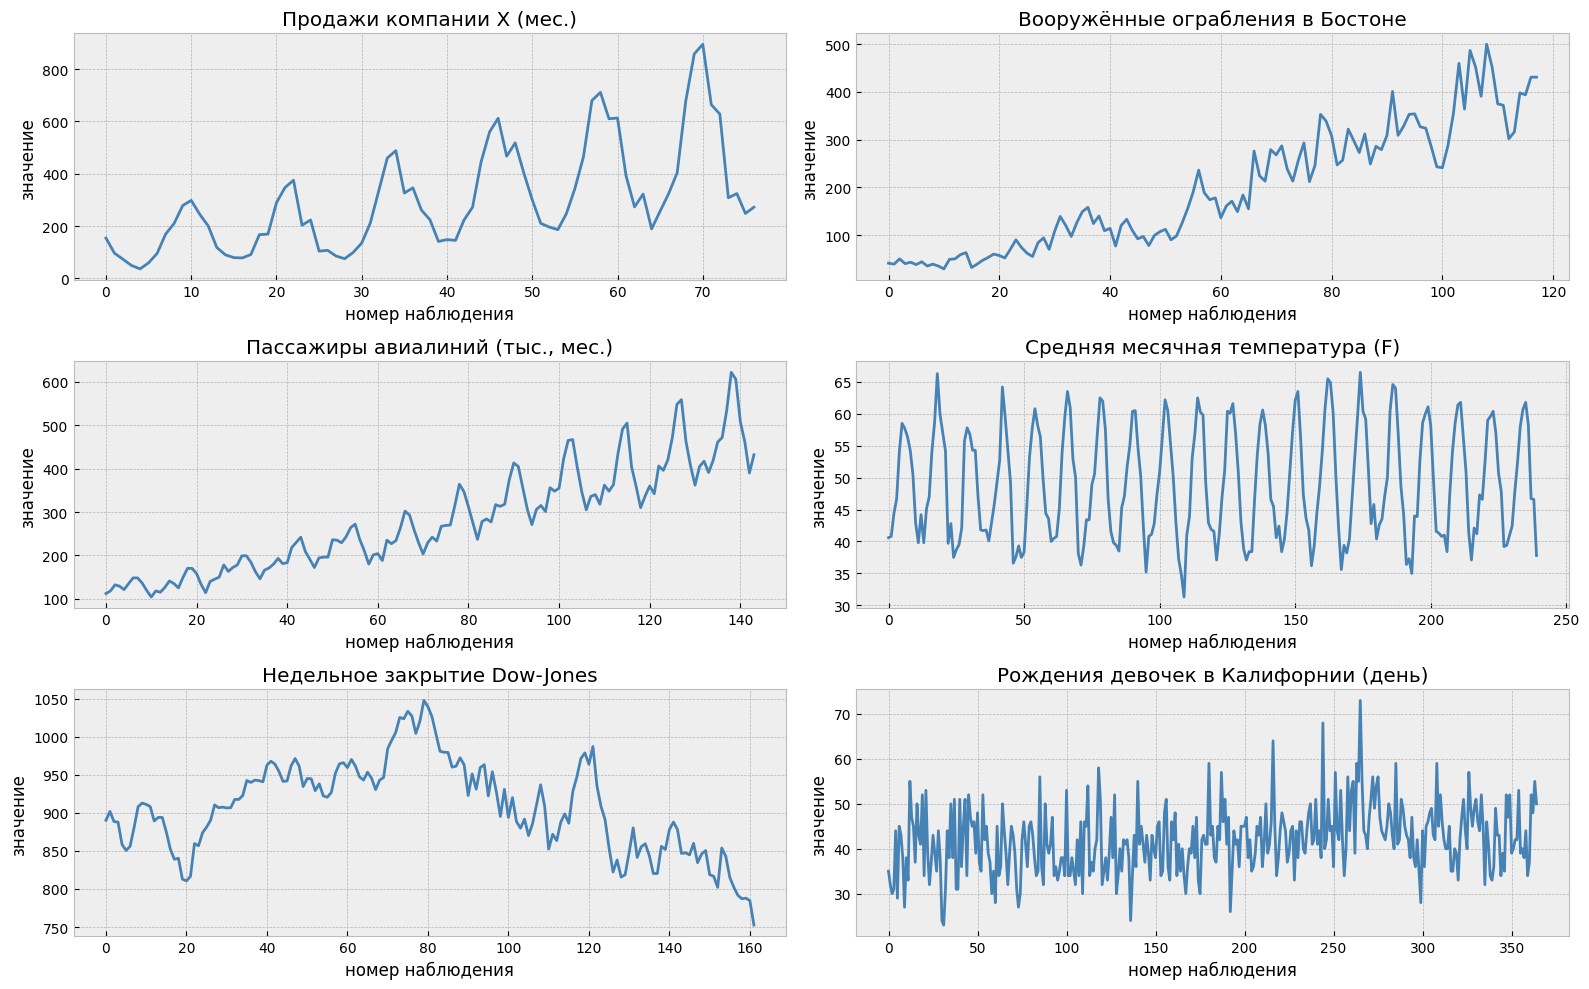

In [3]:
with plt.style.context('bmh'):
    plt.figure(figsize=(16, 10))
    for i, (name, s) in enumerate(all_series.items()):
        ax = plt.subplot(3, 2, i + 1)
        s.plot(ax=ax, color='steelblue')
        ax.set_title(name)
        ax.set_xlabel("номер наблюдения")
        ax.set_ylabel("значение")
    plt.tight_layout()
    plt.show()

Что видно:
- **Продажи X** и **ограбления** — явный растущий тренд плюс годовая сезонность, причём амплитуда колебаний растёт вместе с уровнем (значит, дисперсию надо стабилизировать).
- **Пассажиры авиалиний** — классика: тренд вверх + сезонность с растущим размахом.
- **Температура** — тренда почти нет, но мощная годовая сезонность (12 месяцев).
- **Dow-Jones** — похоже на случайное блуждание, тренд есть, сезонности нет.
- **Рождения** — почти ровный ряд без выраженного тренда, скорее всего уже близок к стационарному.

Дальше — тест Дики-Фуллера, чтобы не гадать на глаз.

## Тест Дики-Фуллера

Оформлю проверку функцией, чтобы переиспользовать. Нулевая гипотеза теста — ряд **не** стационарен (есть единичный корень). Значит, хотим маленький p-value (< 0.05), тогда нулевую гипотезу отклоняем и считаем ряд стационарным.

In [4]:
def test_stationarity(timeseries, name=""):
    ts = pd.Series(timeseries).dropna()
    result = adfuller(ts, autolag='AIC')
    out = pd.Series(result[0:4],
                    index=['Статистика', 'p-value', 'Лагов', 'Наблюдений'])
    for key, value in result[4].items():
        out[f'Крит. значение ({key})'] = value
    verdict = "СТАЦИОНАРЕН" if result[1] < 0.05 else "НЕ стационарен"
    print(f"--- {name} ---")
    print(out.to_string())
    print(f"Вывод: {verdict} (p-value = {result[1]:.4g})\n")
    return result[1]

Прогоню тест по исходным рядам — чтобы было с чем сравнивать после преобразований.

In [5]:
print("ИСХОДНЫЕ РЯДЫ:\n")
for name, s in all_series.items():
    test_stationarity(s, name)

ИСХОДНЫЕ РЯДЫ:

--- Продажи компании X (мес.) ---
Статистика               0.654715
p-value                  0.988889
Лагов                   12.000000
Наблюдений              64.000000
Крит. значение (1%)     -3.536928
Крит. значение (5%)     -2.907887
Крит. значение (10%)    -2.591493
Вывод: НЕ стационарен (p-value = 0.9889)

--- Вооружённые ограбления в Бостоне ---
Статистика                1.001102
p-value                   0.994278
Лагов                    11.000000
Наблюдений              106.000000
Крит. значение (1%)      -3.493602
Крит. значение (5%)      -2.889217
Крит. значение (10%)     -2.581533
Вывод: НЕ стационарен (p-value = 0.9943)

--- Пассажиры авиалиний (тыс., мес.) ---
Статистика                0.815369
p-value                   0.991880
Лагов                    13.000000
Наблюдений              130.000000
Крит. значение (1%)      -3.481682
Крит. значение (5%)      -2.884042
Крит. значение (10%)     -2.578770
Вывод: НЕ стационарен (p-value = 0.9919)

--- Средняя ме

Как и ожидалось: ряды с трендом и сезонностью тест не проходят. Рождения, скорее всего, уже стационарны. Теперь беру каждый ряд отдельно и привожу к стационарности.

Заведу пару хелперов: один рисует «до/после», второй — коррелограммы (ACF/PACF), чтобы видеть, осталась ли автокорреляция.

In [6]:
def show_before_after(orig, transformed, title):
    with plt.style.context('bmh'):
        fig, axes = plt.subplots(1, 2, figsize=(16, 4))
        pd.Series(orig).plot(ax=axes[0], color='gray')
        axes[0].set_title(f"{title} — исходный")
        axes[0].set_xlabel("наблюдение"); axes[0].set_ylabel("значение")
        pd.Series(transformed).plot(ax=axes[1], color='steelblue')
        axes[1].set_title(f"{title} — после преобразований")
        axes[1].set_xlabel("наблюдение"); axes[1].set_ylabel("значение")
        plt.tight_layout()
        plt.show()

def plot_acf_pacf(ts, lags, title):
    ts = pd.Series(ts).dropna()
    with plt.style.context('bmh'):
        fig, axes = plt.subplots(1, 2, figsize=(16, 4))
        smt.graphics.plot_acf(ts, lags=lags, ax=axes[0], alpha=0.05)
        smt.graphics.plot_pacf(ts, lags=lags, ax=axes[1], alpha=0.05)
        axes[0].set_title(f"ACF — {title}")
        axes[1].set_title(f"PACF — {title}")
        plt.tight_layout()
        plt.show()

## 1. Продажи компании X

Тренд + сезонность + растущий разброс. Логика: сначала логарифм (Бокс-Кокс с λ=0, чтобы прибить рост дисперсии), потом обычное дифференцирование на единицу — снимаем тренд. Сезонное дифференцирование я пробовал, но оно ряд переразностило (тест после него проходит хуже), так что оставляю только log + diff(1).

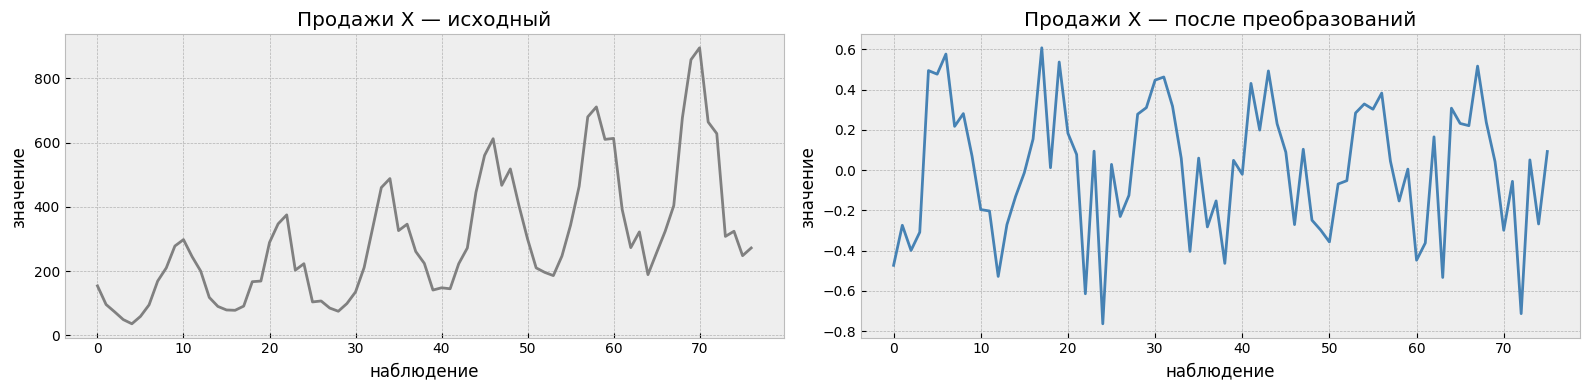

--- Продажи X — после log + diff(1) ---
Статистика              -3.135644
p-value                  0.024025
Лагов                   11.000000
Наблюдений              64.000000
Крит. значение (1%)     -3.536928
Крит. значение (5%)     -2.907887
Крит. значение (10%)    -2.591493
Вывод: СТАЦИОНАРЕН (p-value = 0.02403)



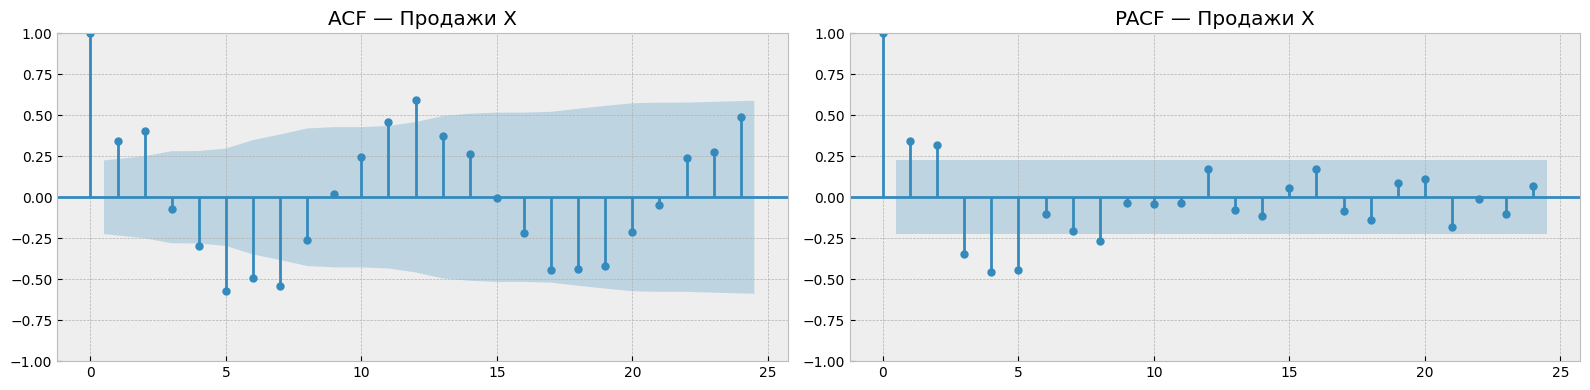

In [7]:
s = all_series["Продажи компании X (мес.)"]

bc = boxcox(s, 0)            # λ=0 это логарифм, гасит растущую дисперсию
d = np.diff(bc, n=1)         # одно обычное дифференцирование убирает тренд

show_before_after(s, d, "Продажи X")
test_stationarity(d, "Продажи X — после log + diff(1)")
plot_acf_pacf(d, lags=24, title="Продажи X")

После логарифма и одного дифференцирования p-value уходит ниже 0.05 — ряд стационарен. Добавлять сезонное дифференцирование смысла нет: ряд короткий, и второй шаг только ухудшает тест (классическое переразностивание).

## 2. Вооружённые ограбления в Бостоне

Похож на продажи: сильный рост и расширяющиеся колебания. Беру тот же рецепт — лог + дифференцирование. Сезонное диф. тоже добавлю (данные месячные, лаг 12).

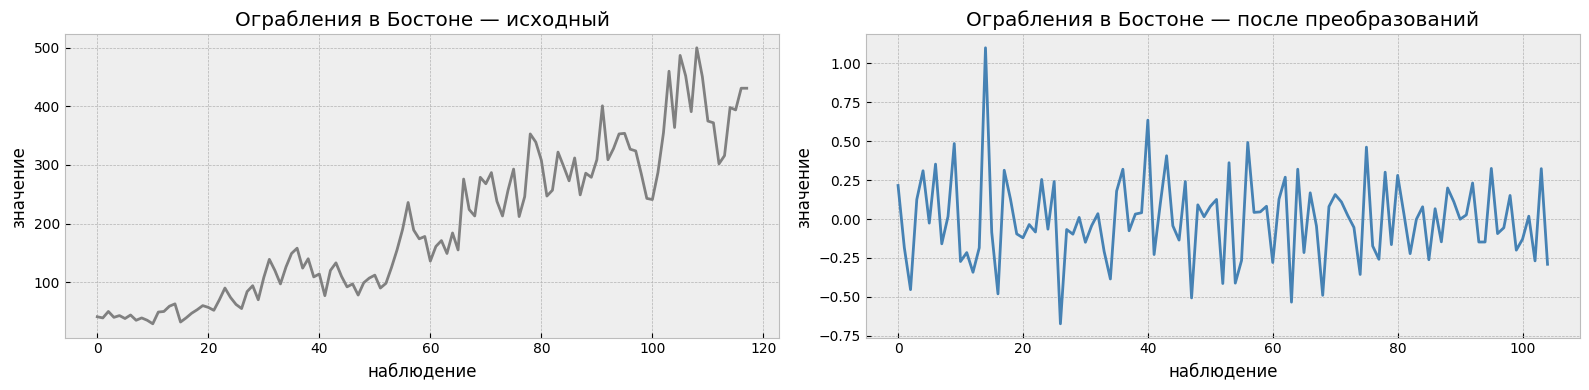

--- Ограбления — после log + diff(1) + seasonal diff(12) ---
Статистика              -4.232984
p-value                  0.000579
Лагов                   13.000000
Наблюдений              91.000000
Крит. значение (1%)     -3.504343
Крит. значение (5%)     -2.893866
Крит. значение (10%)    -2.584015
Вывод: СТАЦИОНАРЕН (p-value = 0.0005791)



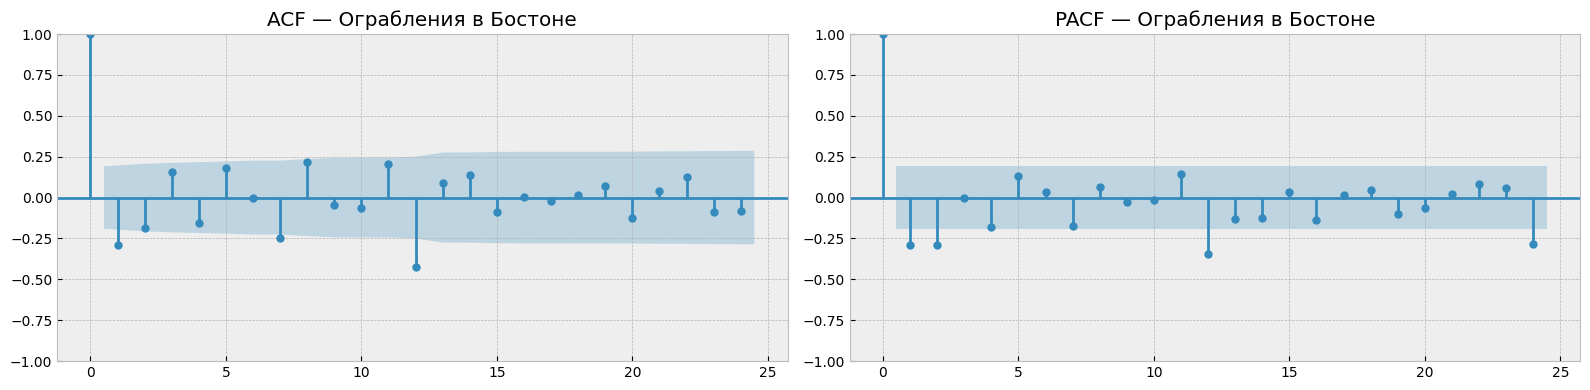

In [8]:
s = all_series["Вооружённые ограбления в Бостоне"]

bc = boxcox(s, 0)
d = np.diff(bc, n=1)
d = pd.Series(d).diff(12).dropna().values

show_before_after(s, d, "Ограбления в Бостоне")
test_stationarity(d, "Ограбления — после log + diff(1) + seasonal diff(12)")
plot_acf_pacf(d, lags=24, title="Ограбления в Бостоне")

Тоже стационарен: разброс выровнялся, тренд ушёл, p-value маленький.

## 3. Пассажиры авиалиний

Самый «учебный» ряд — на нём обычно и показывают приведение к стационарности. Растущий тренд и сезонность с расширяющейся амплитудой. Рецепт ровно тот же: лог, потом diff(1) убирает тренд, diff(12) — годовую сезонность.

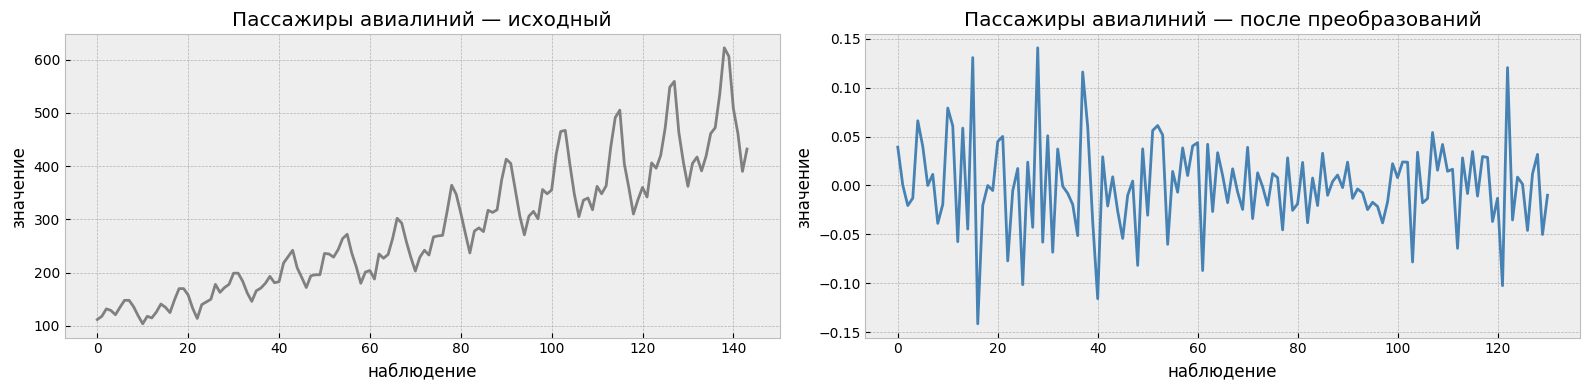

--- Пассажиры — после log + diff(1) + seasonal diff(12) ---
Статистика               -4.443325
p-value                   0.000249
Лагов                    12.000000
Наблюдений              118.000000
Крит. значение (1%)      -3.487022
Крит. значение (5%)      -2.886363
Крит. значение (10%)     -2.580009
Вывод: СТАЦИОНАРЕН (p-value = 0.0002486)



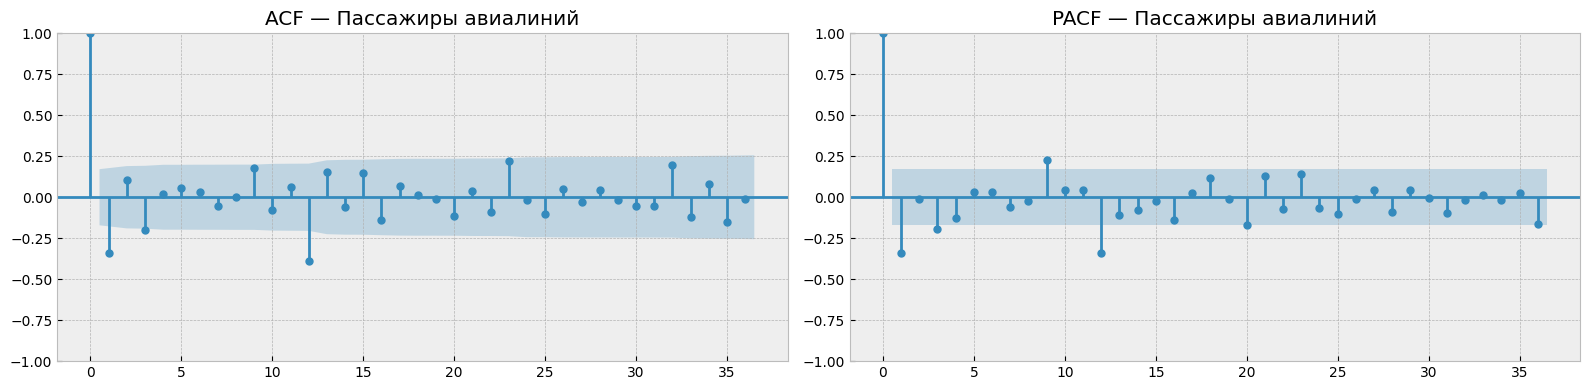

In [9]:
s = all_series["Пассажиры авиалиний (тыс., мес.)"]

bc = boxcox(s, 0)
d = np.diff(bc, n=1)
d = pd.Series(d).diff(12).dropna().values

show_before_after(s, d, "Пассажиры авиалиний")
test_stationarity(d, "Пассажиры — после log + diff(1) + seasonal diff(12)")
plot_acf_pacf(d, lags=36, title="Пассажиры авиалиний")

Дисперсия стала ровной по всей длине, тренда нет, тест проходит. Классический результат.

## 4. Средняя месячная температура

Здесь история другая: тренда почти нет, зато очень чёткая годовая сезонность (зима-лето). Дисперсия стабильная, так что Бокс-Кокс не нужен. Достаточно сезонного дифференцирования с лагом 12.

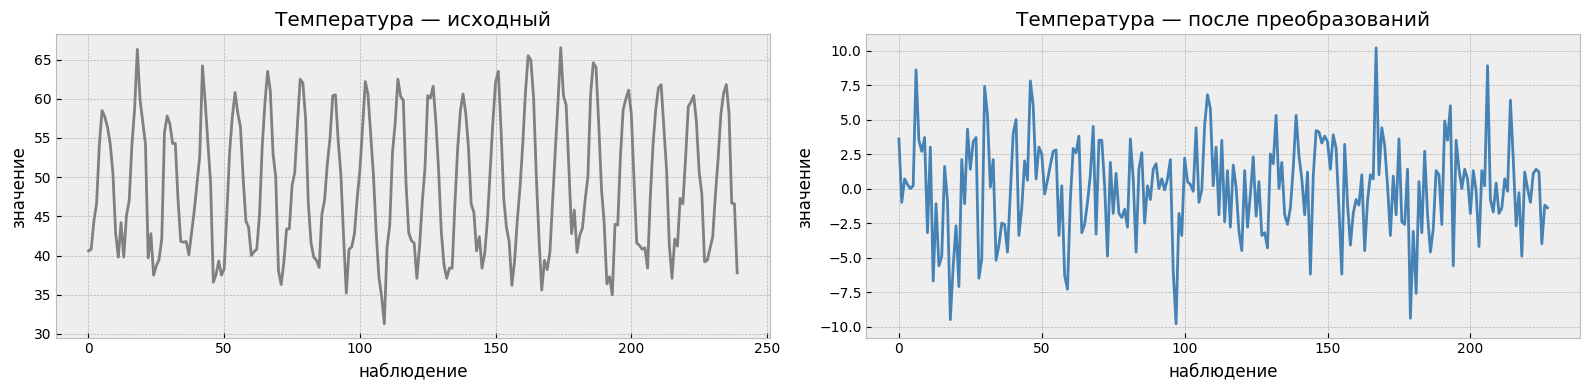

--- Температура — после seasonal diff(12) ---
Статистика             -6.072501e+00
p-value                 1.141945e-07
Лагов                   1.200000e+01
Наблюдений              2.150000e+02
Крит. значение (1%)    -3.461136e+00
Крит. значение (5%)    -2.875079e+00
Крит. значение (10%)   -2.573986e+00
Вывод: СТАЦИОНАРЕН (p-value = 1.142e-07)



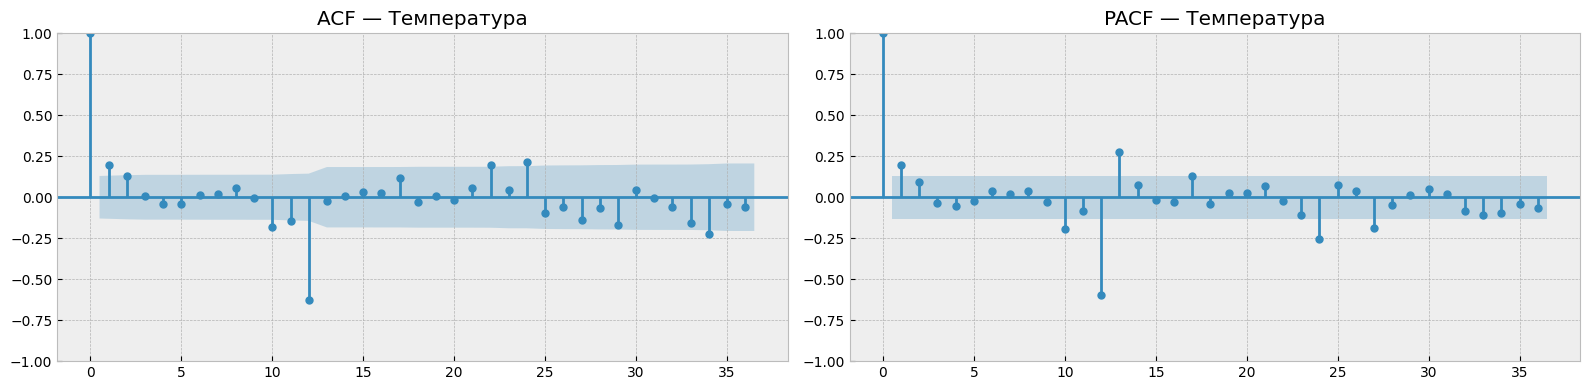

In [10]:
s = all_series["Средняя месячная температура (F)"]

d = s.diff(12).dropna().values    # только сезонное дифференцирование

show_before_after(s, d, "Температура")
test_stationarity(d, "Температура — после seasonal diff(12)")
plot_acf_pacf(d, lags=36, title="Температура")

Одно сезонное дифференцирование убирает синусоиду — ряд становится стационарным. Логарифм тут не нужен, разброс и так не растёт.

## 5. Недельное закрытие Dow-Jones

Биржевой ряд ведёт себя как случайное блуждание: уровень плавает, выраженной сезонности нет. Для такого обычно хватает одного обычного дифференцирования (переход к приращениям).

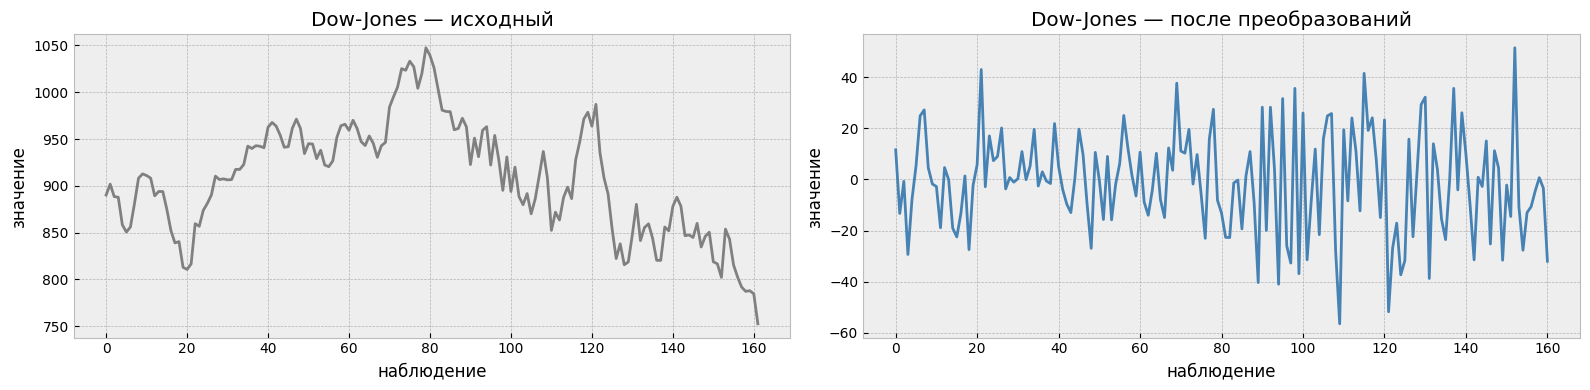

--- Dow-Jones — после diff(1) ---
Статистика             -1.302521e+01
p-value                 2.407586e-24
Лагов                   0.000000e+00
Наблюдений              1.600000e+02
Крит. значение (1%)    -3.471896e+00
Крит. значение (5%)    -2.879780e+00
Крит. значение (10%)   -2.576495e+00
Вывод: СТАЦИОНАРЕН (p-value = 2.408e-24)



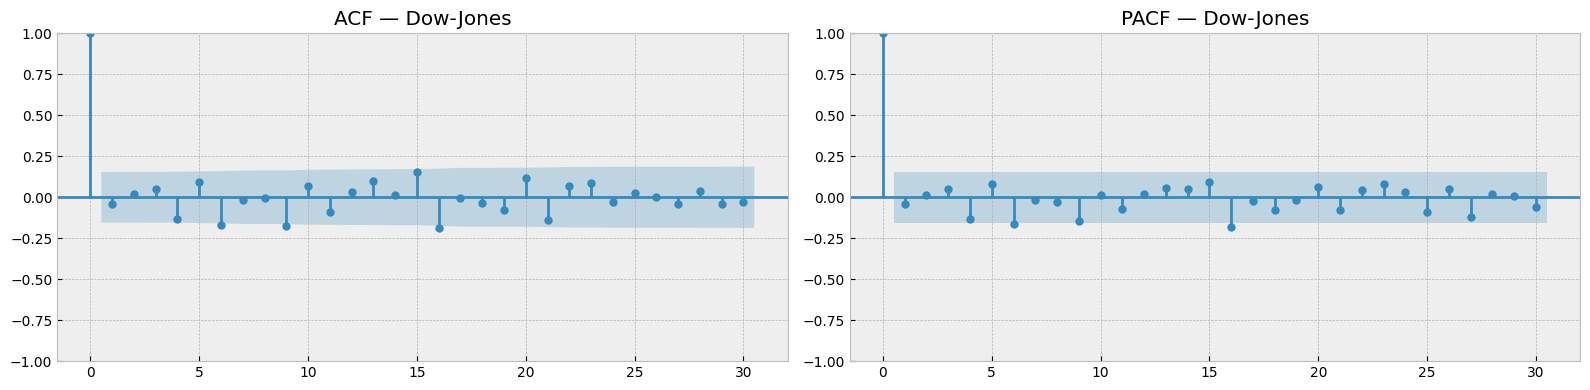

In [11]:
s = all_series["Недельное закрытие Dow-Jones"]

d = np.diff(s, n=1)               # первые разности

show_before_after(s, d, "Dow-Jones")
test_stationarity(d, "Dow-Jones — после diff(1)")
plot_acf_pacf(d, lags=30, title="Dow-Jones")

После перехода к приращениям ряд колеблется вокруг нуля без тренда, тест проходит. Сезонность не трогал — её тут нет.

## 6. Рождения девочек в Калифорнии

Этот ряд изначально выглядел почти стационарным: ровный уровень, без тренда и сезонности. Проверим — возможно, преобразования вообще не нужны, а если ADF на исходном ряде даёт пограничный результат, добавлю одно дифференцирование.

--- Рождения — исходный ряд ---
Статистика               -4.808291
p-value                   0.000052
Лагов                     6.000000
Наблюдений              358.000000
Крит. значение (1%)      -3.448749
Крит. значение (5%)      -2.869647
Крит. значение (10%)     -2.571089
Вывод: СТАЦИОНАРЕН (p-value = 5.243e-05)

>> Ряд уже стационарен, дифференцирование не требуется.


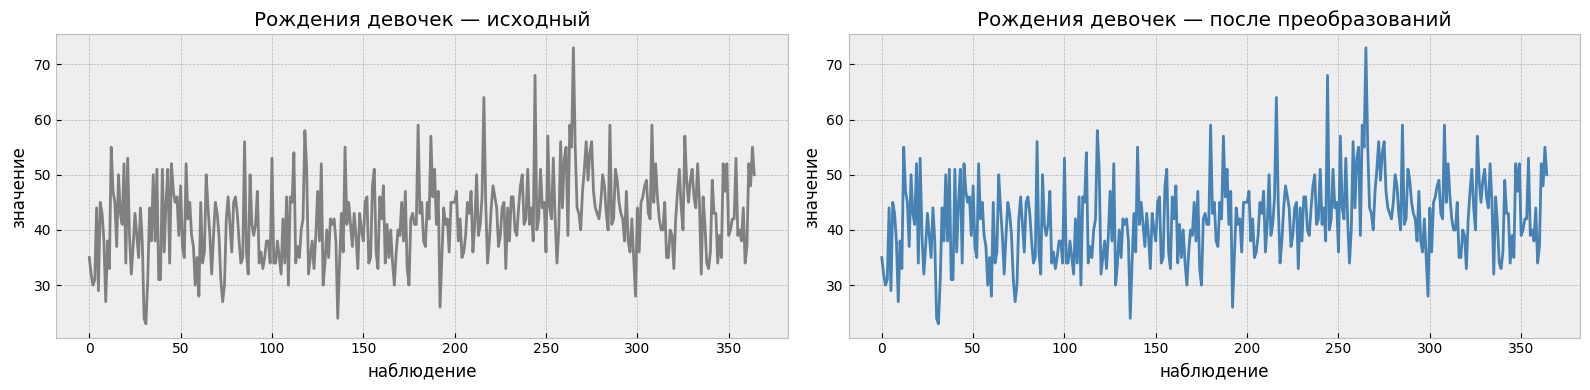

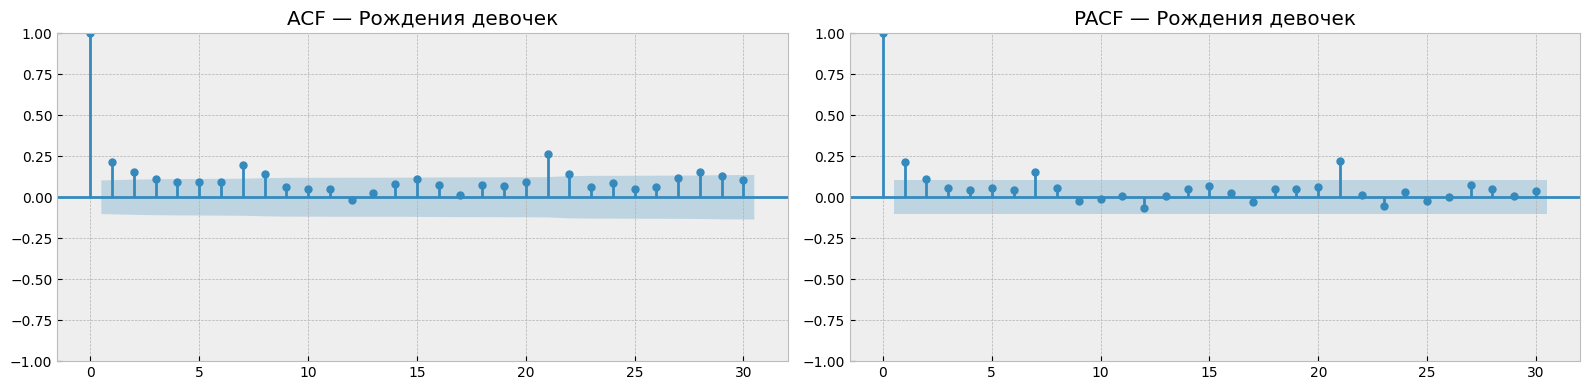

In [12]:
s = all_series["Рождения девочек в Калифорнии (день)"]

p_orig = test_stationarity(s, "Рождения — исходный ряд")

if p_orig < 0.05:
    print(">> Ряд уже стационарен, дифференцирование не требуется.")
    d = s.values
else:
    print(">> Берём первые разности.")
    d = np.diff(s, n=1)
    test_stationarity(d, "Рождения — после diff(1)")

show_before_after(s, d, "Рождения девочек")
plot_acf_pacf(d, lags=30, title="Рождения девочек")

Как и предполагали по графику — ряд стационарен уже в исходном виде (p-value заметно меньше 0.05), дополнительные преобразования не нужны.

## Итоги

Свёл всё в таблицу: что за ряд, какие преобразования понадобились и прошёл ли он тест.

| Ряд | Преобразование | Итог |
|---|---|---|
| Продажи компании X | log + diff(1) | стационарен |
| Ограбления в Бостоне | log + diff(1) + сезонное diff(12) | стационарен |
| Пассажиры авиалиний | log + diff(1) + сезонное diff(12) | стационарен |
| Температура | сезонное diff(12) | стационарен |
| Dow-Jones | diff(1) | стационарен |
| Рождения девочек | без преобразований | уже стационарен |

**Вывод.** Подход к каждому ряду диктуется его природой. Где разброс рос вместе с уровнем (продажи, ограбления, пассажиры) — сначала логарифм, иначе дифференцирование не выравнивает дисперсию. Тренд снимается обычным дифференцированием, а годовую сезонность убирает сезонное дифференцирование с лагом 12 (понадобилось ограблениям и пассажирам). У продаж ряд короткий, и сезонный шаг его переразностил — хватило одного обычного дифференцирования. У температуры тренда нет, поэтому хватило одного сезонного дифференцирования; у Dow-Jones, наоборот, нет сезонности, и сработало простое diff(1). Ряд рождений оказался стационарным с самого начала. Во всех случаях тест Дики-Фуллера подтвердил результат (p-value < 0.05), а коррелограммы показали, что выраженной структуры после преобразований почти не осталось.